In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


Q1. Manual Histogram Equalization on a 4-bit Sample Image Matrix

Saving cv co2 at1 picture reference.jpg to cv co2 at1 picture reference.jpg


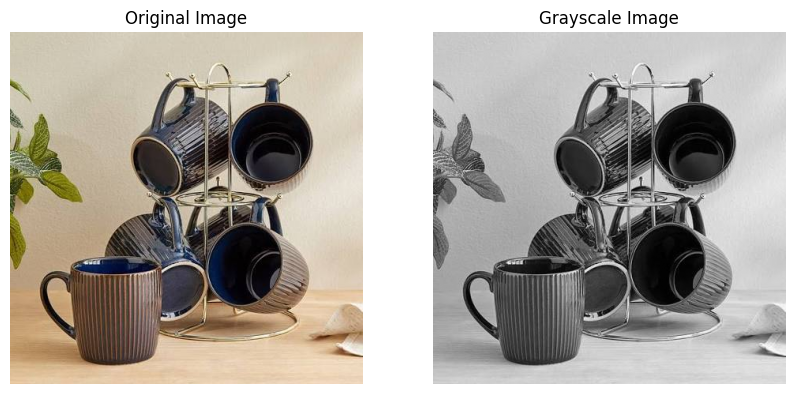

In [3]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded file name
filename = next(iter(uploaded))

# Read image
image = cv2.imread(filename)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display Original and Grayscale Images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

Q2. Implementing Negative and Log Transformations

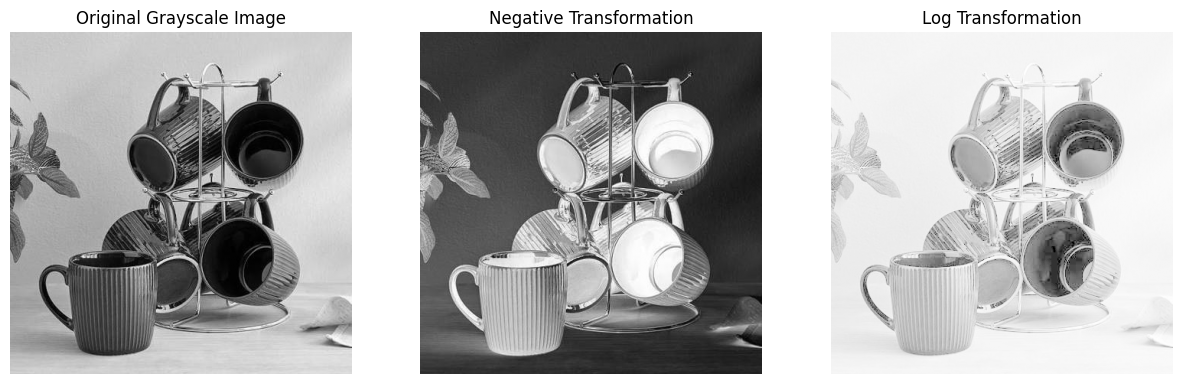

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Negative Transformation
negative = 255 - gray

# Log Transformation
c = 255 / np.log(1 + np.max(gray))
log_image = c * np.log(1 + gray.astype(np.float32))
log_image = np.array(log_image, dtype=np.uint8)

# Display Results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(negative, cmap='gray')
plt.title("Negative Transformation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(log_image, cmap='gray')
plt.title("Log Transformation")
plt.axis("off")

plt.show()

Q3. Power-Law (Gamma) Transformation

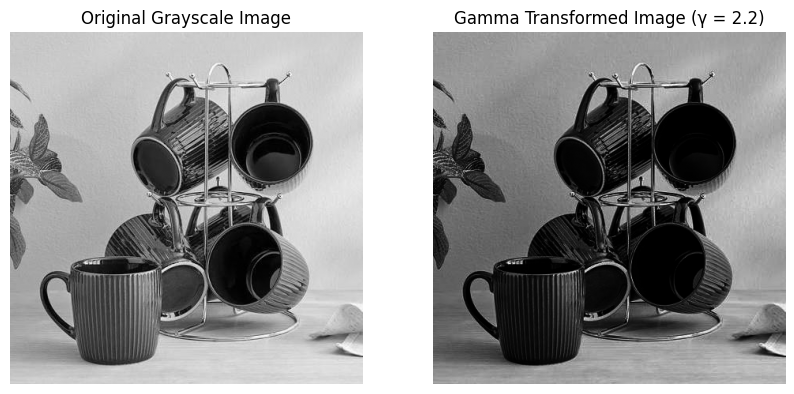

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Gamma value
gamma = 2.2

# Normalize image
normalized = gray / 255.0

# Apply Gamma Transformation
gamma_image = np.power(normalized, gamma)

# Convert back to 8-bit image
gamma_image = np.uint8(gamma_image * 255)

# Display Images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gamma_image, cmap='gray')
plt.title("Gamma Transformed Image (γ = 2.2)")
plt.axis("off")

plt.show()

Q4. Piecewise-Linear Contrast Stretching

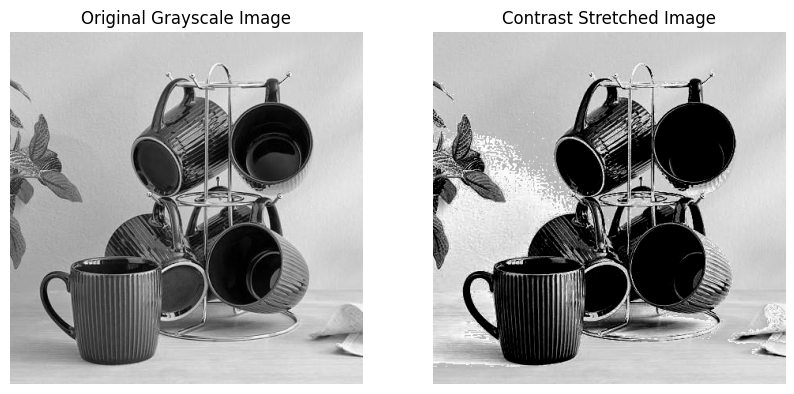

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define lower and upper intensity limits
r1 = 70
r2 = 180
s1 = 0
s2 = 255

# Create output image
contrast = np.zeros_like(gray)

# Apply Piecewise-Linear Contrast Stretching
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        pixel = gray[i, j]

        if pixel < r1:
            contrast[i, j] = (s1 / r1) * pixel if r1 != 0 else 0

        elif pixel <= r2:
            contrast[i, j] = ((s2 - s1) / (r2 - r1)) * (pixel - r1) + s1

        else:
            contrast[i, j] = pixel

# Convert to uint8
contrast = np.clip(contrast, 0, 255).astype(np.uint8)

# Display Images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(contrast, cmap='gray')
plt.title("Contrast Stretched Image")
plt.axis("off")

plt.show()

Q5. Mean (Average) Filter

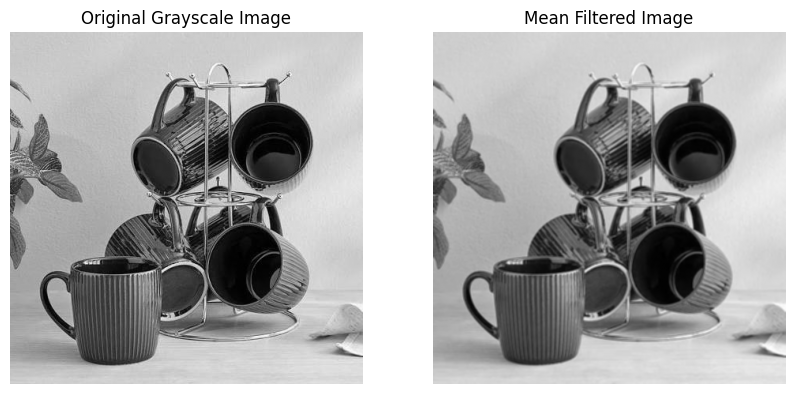

In [7]:
import cv2
import matplotlib.pyplot as plt

# Apply Mean (Average) Filter
mean_filtered = cv2.blur(gray, (3, 3))

# Display Images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mean_filtered, cmap='gray')
plt.title("Mean Filtered Image")
plt.axis("off")

plt.show()

Q6. Median Filter

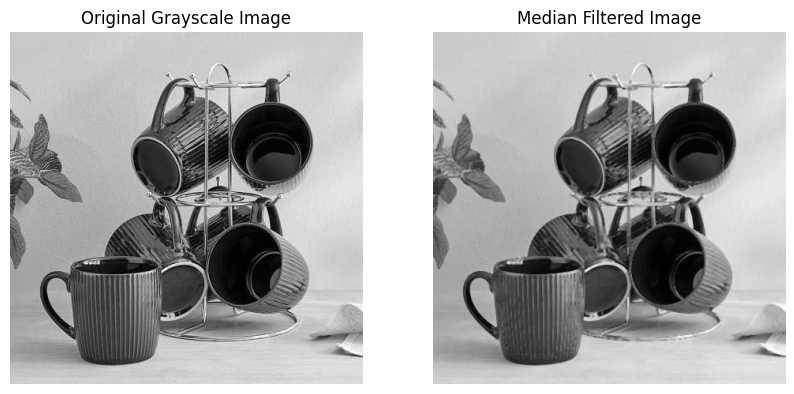

In [8]:
import cv2
import matplotlib.pyplot as plt

# Apply Median Filter
median_filtered = cv2.medianBlur(gray, 3)

# Display Images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filtered Image")
plt.axis("off")

plt.show()

Q7. Laplacian Sharpening

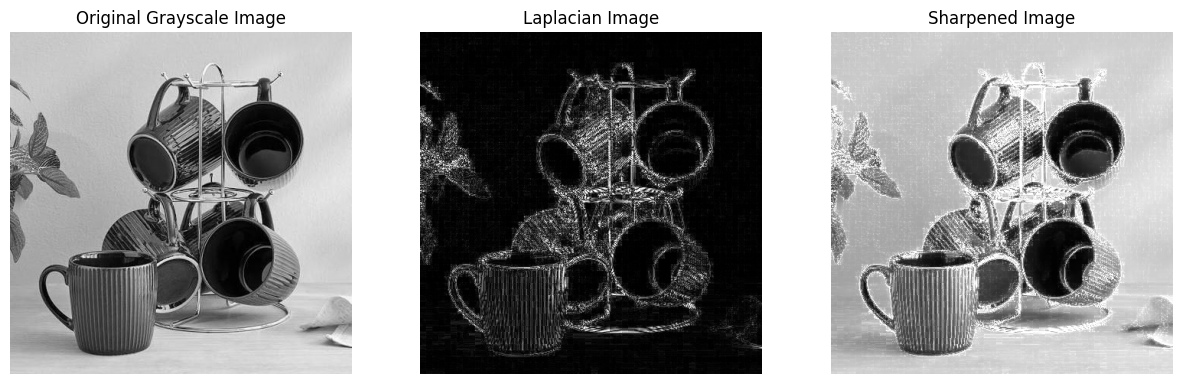

In [9]:
import cv2
import matplotlib.pyplot as plt

# Apply Laplacian filter
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Convert to 8-bit image
laplacian = cv2.convertScaleAbs(laplacian)

# Sharpen the image
sharpened = cv2.add(gray, laplacian)

# Display Images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis("off")

plt.show()

Q8. High-Boost Filtering

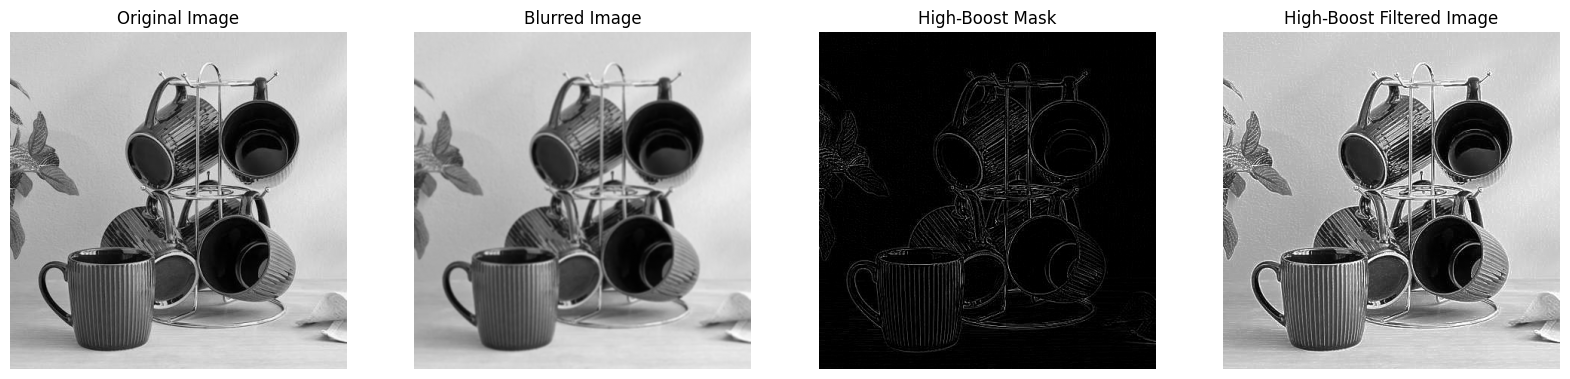

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Blur the image using Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Create High-Boost Mask
mask = cv2.subtract(gray, blurred)

# Boost Factor
k = 2.0

# Apply High-Boost Filtering
high_boost = cv2.addWeighted(gray, 1.0, mask, k, 0)

# Display Images
plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask, cmap='gray')
plt.title("High-Boost Mask")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(high_boost, cmap='gray')
plt.title("High-Boost Filtered Image")
plt.axis("off")

plt.show()

Q9. Frequency-Domain Low-Pass Filtering

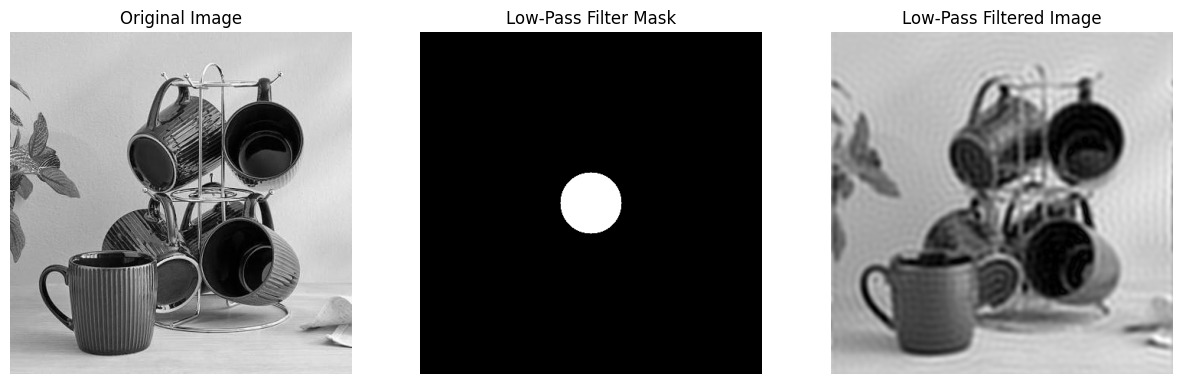

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Perform Fourier Transform
dft = np.fft.fft2(gray)
dft_shift = np.fft.fftshift(dft)

# Create Low-Pass Filter Mask
rows, cols = gray.shape
crow, ccol = rows // 2, cols // 2

mask = np.zeros((rows, cols), np.uint8)
radius = 40

for i in range(rows):
    for j in range(cols):
        if (i - crow)**2 + (j - ccol)**2 <= radius**2:
            mask[i, j] = 1

# Apply Mask
filtered = dft_shift * mask

# Inverse Fourier Transform
inverse_shift = np.fft.ifftshift(filtered)
inverse_image = np.fft.ifft2(inverse_shift)
low_pass = np.abs(inverse_image)

# Display Images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Low-Pass Filter Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(low_pass, cmap='gray')
plt.title("Low-Pass Filtered Image")
plt.axis("off")

plt.show()

Q10. Frequency-Domain High-Pass Filtering

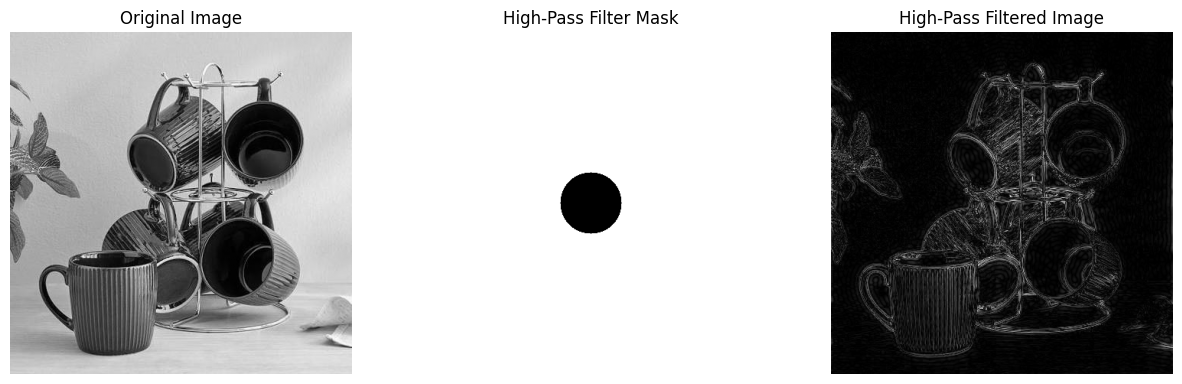

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Perform Fourier Transform
dft = np.fft.fft2(gray)
dft_shift = np.fft.fftshift(dft)

# Create High-Pass Filter Mask
rows, cols = gray.shape
crow, ccol = rows // 2, cols // 2

mask = np.ones((rows, cols), np.uint8)
radius = 40

for i in range(rows):
    for j in range(cols):
        if (i - crow)**2 + (j - ccol)**2 <= radius**2:
            mask[i, j] = 0

# Apply High-Pass Mask
filtered = dft_shift * mask

# Inverse Fourier Transform
inverse_shift = np.fft.ifftshift(filtered)
inverse_image = np.fft.ifft2(inverse_shift)
high_pass = np.abs(inverse_image)

# Display Images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("High-Pass Filter Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(high_pass, cmap='gray')
plt.title("High-Pass Filtered Image")
plt.axis("off")

plt.show()

Q11. Point Detection Using Laplacian-Based Mask

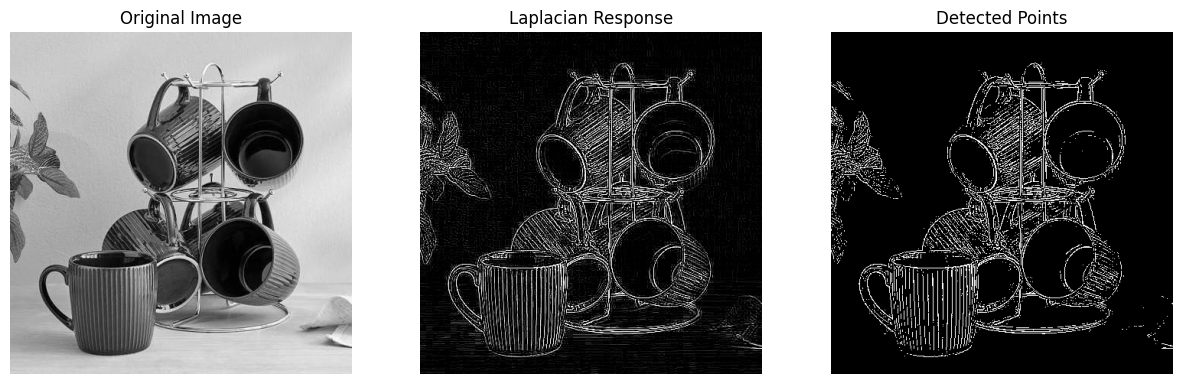

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Laplacian-based point detection mask
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

# Apply the mask
point_detect = cv2.filter2D(gray, -1, kernel)

# Threshold the result to highlight detected points
_, detected_points = cv2.threshold(point_detect, 120, 255, cv2.THRESH_BINARY)

# Display Images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(point_detect, cmap='gray')
plt.title("Laplacian Response")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(detected_points, cmap='gray')
plt.title("Detected Points")
plt.axis("off")

plt.show()

Q12. Line Detection Using Directional Masks

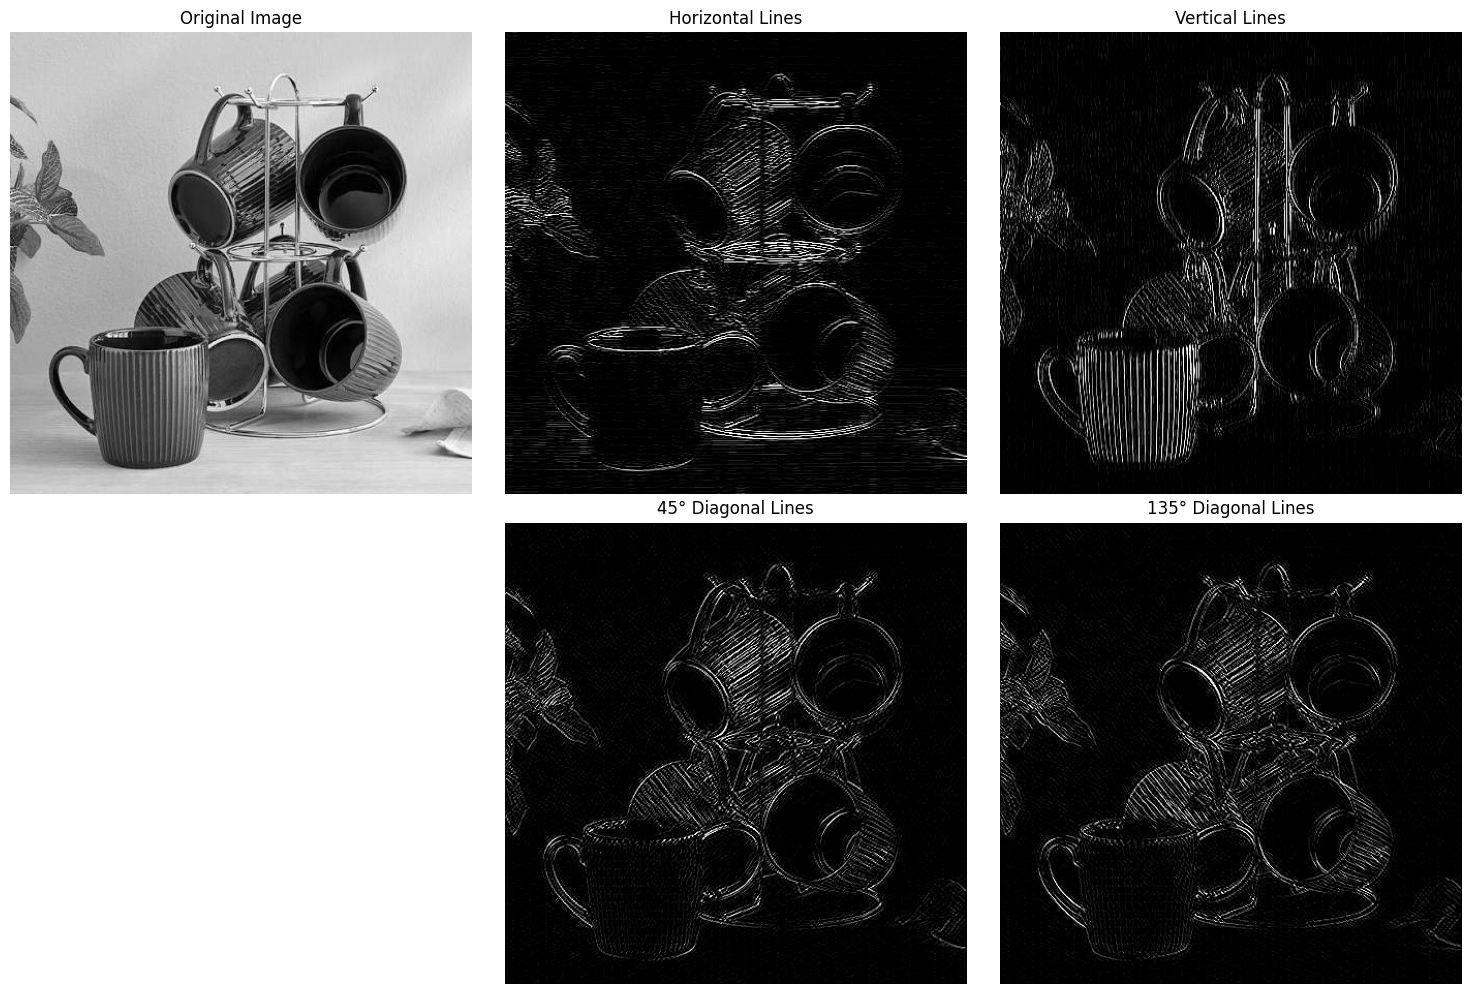

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Horizontal line mask
horizontal_kernel = np.array([
    [-1, -1, -1],
    [ 2,  2,  2],
    [-1, -1, -1]
], dtype=np.float32)

# Vertical line mask
vertical_kernel = np.array([
    [-1,  2, -1],
    [-1,  2, -1],
    [-1,  2, -1]
], dtype=np.float32)

# 45° Diagonal line mask
diagonal45_kernel = np.array([
    [-1, -1,  2],
    [-1,  2, -1],
    [ 2, -1, -1]
], dtype=np.float32)

# 135° Diagonal line mask
diagonal135_kernel = np.array([
    [ 2, -1, -1],
    [-1,  2, -1],
    [-1, -1,  2]
], dtype=np.float32)

# Apply directional masks
horizontal = cv2.filter2D(gray, -1, horizontal_kernel)
vertical = cv2.filter2D(gray, -1, vertical_kernel)
diagonal45 = cv2.filter2D(gray, -1, diagonal45_kernel)
diagonal135 = cv2.filter2D(gray, -1, diagonal135_kernel)

# Display Results
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(horizontal, cmap='gray')
plt.title("Horizontal Lines")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(vertical, cmap='gray')
plt.title("Vertical Lines")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(diagonal45, cmap='gray')
plt.title("45° Diagonal Lines")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(diagonal135, cmap='gray')
plt.title("135° Diagonal Lines")
plt.axis("off")

plt.tight_layout()
plt.show()

Q13. Otsu's Thresholding

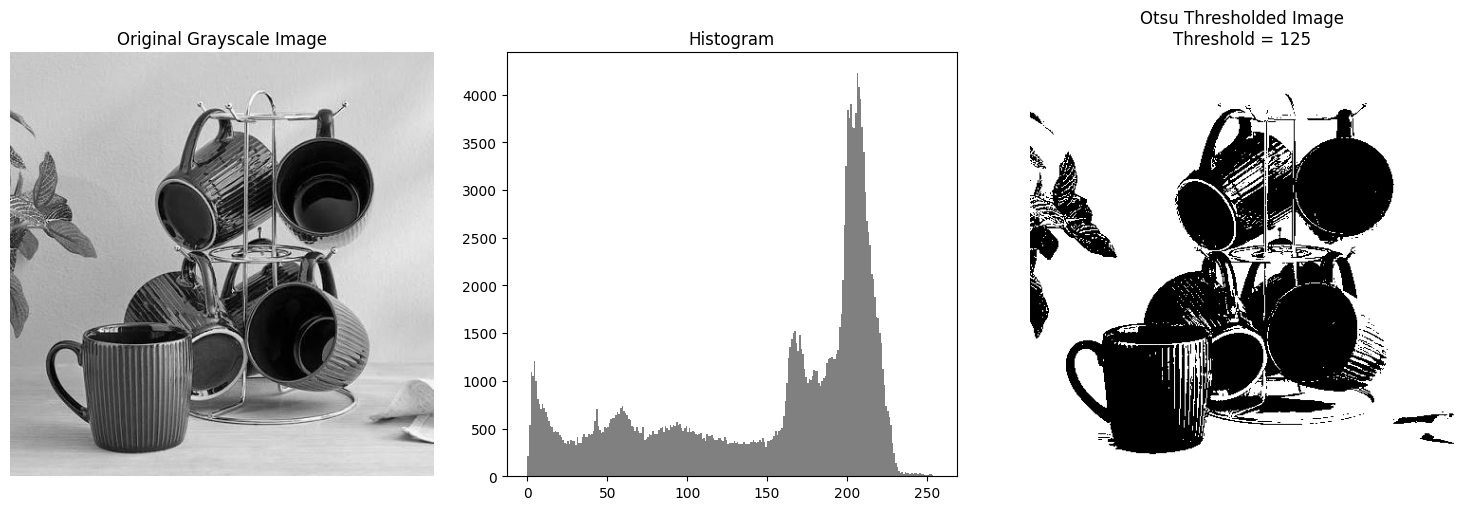

Optimal Threshold Value: 125.0


In [15]:
import cv2
import matplotlib.pyplot as plt

# Apply Otsu's Thresholding
threshold_value, otsu_image = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display Images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.hist(gray.ravel(), bins=256, range=[0,256], color='gray')
plt.title("Histogram")

plt.subplot(1,3,3)
plt.imshow(otsu_image, cmap='gray')
plt.title(f"Otsu Thresholded Image\nThreshold = {threshold_value:.0f}")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Optimal Threshold Value:", threshold_value)

Q14. Region Growing Segmentation

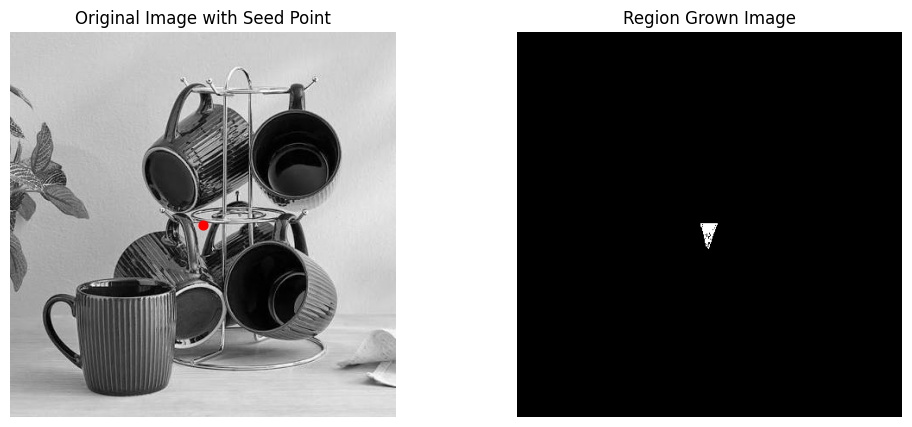

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Seed point (Change these coordinates if needed)
seed_x = gray.shape[1] // 2
seed_y = gray.shape[0] // 2

# Threshold for region growing
threshold = 15

# Initialize segmented image
segmented = np.zeros_like(gray, dtype=np.uint8)

# Visited pixels
visited = np.zeros_like(gray, dtype=bool)

# Queue for region growing
queue = [(seed_y, seed_x)]

seed_value = int(gray[seed_y, seed_x])

# Region Growing Algorithm
while queue:
    y, x = queue.pop(0)

    if visited[y, x]:
        continue

    visited[y, x] = True

    if abs(int(gray[y, x]) - seed_value) <= threshold:
        segmented[y, x] = 255

        # Check 4-connected neighbors
        for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
            ny, nx = y + dy, x + dx

            if 0 <= ny < gray.shape[0] and 0 <= nx < gray.shape[1]:
                if not visited[ny, nx]:
                    queue.append((ny, nx))

# Display Images
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.scatter(seed_x, seed_y, color='red', s=40)
plt.title("Original Image with Seed Point")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='gray')
plt.title("Region Grown Image")
plt.axis("off")

plt.show()

Q15. Edge Linking Using Hough-Based Local Processing

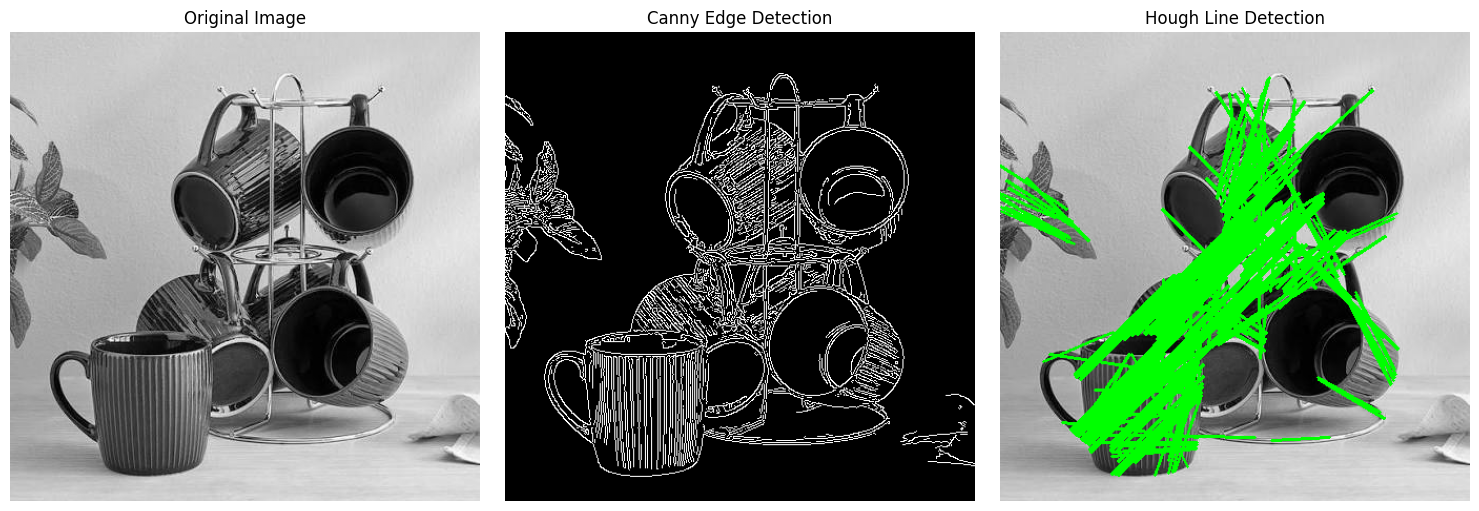

Number of lines detected: 157


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Detect edges using Canny Edge Detector
edges = cv2.Canny(gray, 100, 200)

# Convert grayscale image to color
result = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Detect lines using Probabilistic Hough Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=80,
    minLineLength=50,
    maxLineGap=10
)

# Draw detected lines
if lines is not None:
    lines = lines.reshape(-1, 4)   # Convert to (N,4)
    for x1, y1, x2, y2 in lines:
        cv2.line(result, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Convert BGR to RGB for displaying
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display Images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(result_rgb)
plt.title("Hough Line Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

# Print number of detected lines
if lines is not None:
    print("Number of lines detected:", len(lines))
else:
    print("No lines detected.")